## 1. Initialize ISIMIP Client and Configuration

In [1]:
import climdata as cd
from typing import Optional, Set, List, Dict

# Load configuration (includes query_configs with impact_model, climate_forcing, period)
cfg = cd.load_config()

# Initialize AGRI-ISIMIP client with configuration
agri = cd.AGRI_ISIMIP(cfg.dsinfo.AGRI_ISIMIP)

print("✅ Initialized AGRI-ISIMIP client")
print(f"Configuration has {len(cfg.dsinfo.AGRI_ISIMIP.query_configs)} query configuration(s)")

# Show configured query options
for i, qc in enumerate(cfg.dsinfo.AGRI_ISIMIP.query_configs, 1):
    print(f"  [{i}] Impact Model: {qc['impact_model']}, Climate: {qc['climate_forcing']}, Period: {qc['period']}")

✅ Initialized AGRI-ISIMIP client
Configuration has 1 query configuration(s)
  [1] Impact Model: SIMPLACE-LINTUL5, Climate: mpi-esm1-2-hr, Period: historical


## 2. Query Available Metadata

In [2]:
# Get first configured query option
query_config = cfg.dsinfo.AGRI_ISIMIP.query_configs[0]

impact_model = query_config['impact_model']
climate_forcing = query_config['climate_forcing']
period = query_config['period']

print(f"Querying: {impact_model} / {climate_forcing} / {period}")
print("=" * 70)

# Query metadata from ISIMIP API (paginates through all results)
agri.query_available_metadata(
    impact_model=impact_model,
    climate_forcing=climate_forcing,
    period=period
)

Querying: SIMPLACE-LINTUL5 / mpi-esm1-2-hr / historical
✅ Fetched 288 datasets from ISIMIP API
   Crops: ['mai', 'pot', 'sor', 'soy', 'swh', 'wwh']
   Variables: ['anthday', 'biom', 'evapcum', 'harvyear', 'matyday', 'nincum', 'nleachcum', 'nupcum', 'pirnreqcum', 'plantday', 'plantyear', 'yield']
   Irrigation: ['firr', 'noirr']
   Scenarios: ['historical', 'picontrol']


In [3]:
# Access cached metadata
print("\n📊 Available Metadata:")
print(f"  Crops: {sorted(agri.AVAILABLE_CROPS)}")
print(f"  Variables: {sorted(agri.AVAILABLE_VARIABLES)}")
print(f"  Irrigation: {sorted(agri.AVAILABLE_IRRIGATIONS)}")
print(f"  Scenarios: {sorted(agri.AVAILABLE_SCENARIOS)}")


📊 Available Metadata:
  Crops: ['mai', 'pot', 'sor', 'soy', 'swh', 'wwh']
  Variables: ['anthday', 'biom', 'evapcum', 'harvyear', 'matyday', 'nincum', 'nleachcum', 'nupcum', 'pirnreqcum', 'plantday', 'plantyear', 'yield']
  Irrigation: ['firr', 'noirr']
  Scenarios: ['historical', 'picontrol']


In [4]:
# Download a specific file (example: first crop and variable)
# Uncomment to actually download files
cfg = cd.load_config(overrides=['data_dir=./data'])
if agri.AVAILABLE_CROPS and agri.AVAILABLE_VARIABLES:
    first_crop = 'mai'
    first_var = 'yield'
    period='future'
    agri.cfg = cfg
    agri.fetch(
        impact_model=impact_model,
        climate_forcing=climate_forcing,
        period=period,
        crop=first_crop,
        variable=first_var
    )


🔍 Listing AGRI-ISIMIP files:
   Path: ISIMIP3b/OutputData/agriculture/SIMPLACE-LINTUL5/mpi-esm1-2-hr/future
   Crop: mai
   Variable: yield
✅ Found 10 matching files (from 720 total)

Files found:
----------------------------------------------------------------------------------------------------
  1. simplace-lintul5_mpi-esm1-2-hr_w5e5_picontrol_2015soc_default_yield-mai-firr_global_annual-gs
     Path: ISIMIP3b/OutputData/agriculture/SIMPLACE-LINTUL5/mpi-esm1-2-hr/future/simplace-lintul5_mpi-esm1-2-hr_w5e5_picontrol_2015soc_default_yield-mai-firr_global_annual-gs
     Crop: mai, Irrigation: firr, Variable: yield
     Size: 0.01 GB
  2. simplace-lintul5_mpi-esm1-2-hr_w5e5_picontrol_2015soc_default_yield-mai-noirr_global_annual-gs
     Path: ISIMIP3b/OutputData/agriculture/SIMPLACE-LINTUL5/mpi-esm1-2-hr/future/simplace-lintul5_mpi-esm1-2-hr_w5e5_picontrol_2015soc_default_yield-mai-noirr_global_annual-gs
     Crop: mai, Irrigation: noirr, Variable: yield
     Size: 0.01 GB
  3. simplac

In [5]:
# Load a downloaded file with automatic custom time handling
if agri.downloaded_files:
    file_path = agri.downloaded_files[0]
    print(f"Loading file: {file_path}\n")
    
    # Load with automatic custom time decoding
    ds = agri.load(file_path, use_dask=True)
    
    if ds is not None:
        print(f"\n✅ Successfully loaded dataset!")
        print(f"\nDataset structure:")
        print(f"  Dimensions: {dict(ds.dims)}")
        print(f"  Coordinates: {list(ds.coords)}")
        print(f"  Variables: {list(ds.data_vars)}")
        print(f"\nTime coordinate:")
        if 'time' in ds.coords:
            print(f"  Type: {type(ds.time.values[0])}")
            print(f"  First values: {ds.time.values[:5]}")
            print(f"  Last values: {ds.time.values[-5:]}")
        print(f"\nDataset preview:")
        print(ds)

Loading file: data/AGRI_ISIMIP/SIMPLACE-LINTUL5/mpi-esm1-2-hr/future/mai/yield/firr/simplace-lintul5_mpi-esm1-2-hr_w5e5_picontrol_2015soc_default_yield-mai-firr_global_annual-gs_2015_2100.nc

📂 Loading data/AGRI_ISIMIP/SIMPLACE-LINTUL5/mpi-esm1-2-hr/future/mai/yield/firr/simplace-lintul5_mpi-esm1-2-hr_w5e5_picontrol_2015soc_default_yield-mai-firr_global_annual-gs_2015_2100.nc...


<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


   📅 Detected custom time format: growing seasons since 1601-01-01 00:00:00
   ✅ Converted time coordinates (reference year: 1601)
✅ Loaded dataset with dimensions: {'lat': 360, 'lon': 720, 'time': 86}

✅ Successfully loaded dataset!

Dataset structure:
  Dimensions: {'lat': 360, 'lon': 720, 'time': 86}
  Coordinates: ['lat', 'lon', 'time']
  Variables: ['yield-mai-firr']

Time coordinate:
  Type: <class 'numpy.datetime64'>
  First values: ['2015-01-01T00:00:00.000000000' '2016-01-01T00:00:00.000000000'
 '2017-01-01T00:00:00.000000000' '2018-01-01T00:00:00.000000000'
 '2019-01-01T00:00:00.000000000']
  Last values: ['2096-01-01T00:00:00.000000000' '2097-01-01T00:00:00.000000000'
 '2098-01-01T00:00:00.000000000' '2099-01-01T00:00:00.000000000'
 '2100-01-01T00:00:00.000000000']

Dataset preview:
<xarray.Dataset> Size: 178MB
Dimensions:         (lat: 360, lon: 720, time: 86)
Coordinates:
  * lat             (lat) float64 3kB 89.75 89.25 88.75 ... -88.75 -89.25 -89.75
  * lon             (

/beegfs/muduchuru/pkgs_fnl/climdata/climdata/datasets/AGRI_ISIMIP.py:498: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"✅ Loaded dataset with dimensions: {dict(self.ds.dims)}")
/tmp/ipykernel_2692228/3637508893.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensions: {dict(ds.dims)}")


In [6]:
ds

<xarray.Dataset> Size: 178MB
Dimensions:         (lat: 360, lon: 720, time: 86)
Coordinates:
  * lat             (lat) float64 3kB 89.75 89.25 88.75 ... -88.75 -89.25 -89.75
  * lon             (lon) float64 6kB -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
  * time            (time) datetime64[ns] 688B 2015-01-01 ... 2100-01-01
Data variables:
    yield-mai-firr  (time, lat, lon) float64 178MB dask.array<chunksize=(64, 360, 720), meta=np.ndarray>
Attributes:
    institutions:             ZALF, IRD
    comment:                  Data prepared for ISIMIP3b
    institution:              ZALF, IRD
    contact:                  Tommaso Stella <tommaso.stella@zalf.de>, Babaca...
    isimip_id:                8848e59c-a8c0-498e-b8f8-838994d39e64
    isimip_protocol_version:  886f82168ad951c60814cf9b69308701d0565217
    isimip_qc_pass_date:      2023-06-21 12:07 UTC
    isimip_qc_version:        3.0.2

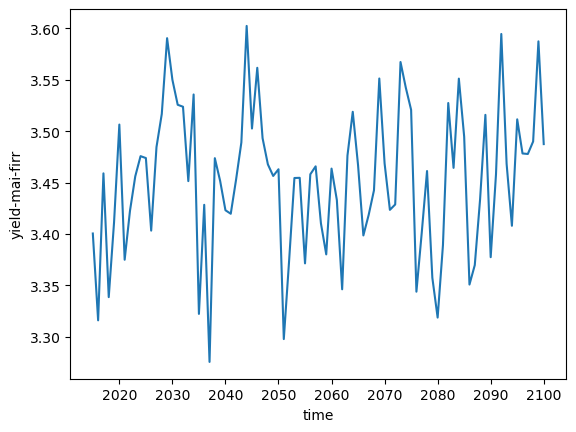

In [8]:
ds.mean(['lat','lon'])['yield-mai-firr'].plot()

## 6. Extract Data by Location (Point/Box)

In [ ]:
# Example: Point extraction
# Requires that data has been loaded in step 5

# # Specify extraction location (lon, lat)
# agri.extract(point=(10.0, 50.0))  # Near Europe
# 
# # Extract data at point
# point_data = agri.get_extracted_data()
# print(f"\nExtracted point data shape: {point_data.dims}")

print("Point extraction example (requires loaded dataset)")

In [ ]:
# Example: Box extraction
# Requires that data has been loaded in step 5

# # Specify extraction box (lon/lat bounds)
# agri.extract(box={
#     'lon_min': 5.0,
#     'lon_max': 15.0,
#     'lat_min': 45.0,
#     'lat_max': 55.0
# })
# 
# # Extract data in box
# box_data = agri.get_extracted_data()
# print(f"\nExtracted box data shape: {box_data.dims}")

print("Box extraction example (requires loaded dataset)")

## 7. Export Extracted Data

In [ ]:
# Example: Save extracted data to CSV
# Requires that data has been extracted in step 6

# agri.save_csv('./extracted_data.csv')
# print("✅ Saved to extracted_data.csv")

print("Export example (requires extracted dataset)")

In [ ]:
# Example: Save extracted data to NetCDF
# Requires that data has been extracted in step 6

# agri.save_netcdf('./extracted_data.nc')
# print("✅ Saved to extracted_data.nc")

print("Export example (requires extracted dataset)")

## Summary

### Key Parameters from Configuration
- **impact_model**: Comes from `cfg.dsinfo.AGRI_ISIMIP.query_configs[].impact_model`
- **climate_forcing**: Comes from `cfg.dsinfo.AGRI_ISIMIP.query_configs[].climate_forcing`
- **period**: Comes from `cfg.dsinfo.AGRI_ISIMIP.query_configs[].period`

### Workflow Steps
1. ✅ Initialize client with config
2. ✅ Query metadata (paginated API calls)
3. ✅ List and filter files by crop/variable/irrigation
4. ✅ Download files with organized directory structure
5. ✅ Load NetCDF with dask for memory efficiency
6. ✅ Extract by point or box
7. ✅ Export to CSV or NetCDF

### Adding More Configurations
Edit `climdata/conf/mappings/parameters.yaml` under `AGRI_ISIMIP.query_configs`:
```yaml
query_configs:
  - impact_model: SIMPLACE-LINTUL5
    climate_forcing: mpi-esm1-2-hr
    period: historical
  - impact_model: OTHER_MODEL
    climate_forcing: other_forcing
    period: future  # Add more as needed
```